# Final Project: Predicting Post-Graduation Earnings from College Characteristics

Julia Lu, Rhea Chellani, DATA 402/403

We use College Scorecard data to predict median earnings 10 years after enrollment. We start with the MVP baseline (linear regression, ridge, lasso), then try log-transforming the target, support vector regression, and a multilayer perceptron. All models get evaluated on the same held-out test set so we can compare them fairly.

## 0. Imports

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.svm import LinearSVR, SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)

## 1. Dataset

We use Most-Recent-Cohorts-Institution.csv from the U.S. Department of Education College Scorecard, one row per school with the most recent data available. The scorecard uses 'PrivacySuppressed' when a cell is suppressed for privacy and 'NULL' when data was not reported. We replace both with NaN and load everything as strings first to avoid pandas type issues.

In [2]:
DATA_PATH = 'College_Scorecard_Raw_Data_03232026/Most-Recent-Cohorts-Institution.csv'

df_raw = pd.read_csv(DATA_PATH, dtype=str, low_memory=False)
df_raw = df_raw.replace('PrivacySuppressed', np.nan)
df_raw = df_raw.replace('NULL', np.nan)

print("shape:", df_raw.shape)

shape: (6322, 3308)


## 2. Feature Selection

The dataset has around 3000 columns so we picked 10 that seemed most relevant to us:

- ADM_RATE: admission rate, a proxy for selectivity
- SAT_AVG: average SAT score, captures academic profile of incoming students
- TUITIONFEE_IN / TUITIONFEE_OUT: in-state and out-of-state tuition
- UGDS: total undergrad enrollment
- C150_4: 4-year graduation rate
- PCTPELL: percent of students on Pell grants, a low income indicator
- PCTFLOAN: percent of students with federal loans
- CONTROL: school type (1=public, 2=private nonprofit, 3=for-profit)
- LOCALE: how urban or rural the school is

Target: MD_EARN_WNE_P10, median earnings 10 years after first enrolling

In [3]:
FEATURES = [
    'ADM_RATE',
    'SAT_AVG',
    'TUITIONFEE_IN',
    'TUITIONFEE_OUT',
    'UGDS',
    'C150_4',
    'PCTPELL',
    'PCTFLOAN',
    'CONTROL',
    'LOCALE',
]
TARGET = 'MD_EARN_WNE_P10'
ID_COLS = ['INSTNM', 'STABBR']

In [4]:
cols_to_keep = ID_COLS + FEATURES + [TARGET]
df = df_raw[cols_to_keep].copy()

for col in FEATURES + [TARGET]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

INSTNM              object
STABBR              object
ADM_RATE           float64
SAT_AVG            float64
TUITIONFEE_IN      float64
TUITIONFEE_OUT     float64
UGDS               float64
C150_4             float64
PCTPELL            float64
PCTFLOAN           float64
CONTROL              int64
LOCALE             float64
MD_EARN_WNE_P10    float64
dtype: object


## 3. EDA

Before modeling we want to understand the data a bit. We check missing values, look at the distribution of the target, and see how features relate to earnings.

In [5]:
missing_rate = df[FEATURES + [TARGET]].isnull().mean().sort_values(ascending=False)

print("missing value rates (sorted):")
for col in missing_rate.index:
    pct = round(missing_rate[col] * 100, 1)
    print(" ", col, str(pct) + "%")

missing value rates (sorted):
  SAT_AVG 83.6%
  ADM_RATE 69.5%
  C150_4 63.9%
  TUITIONFEE_IN 42.1%
  TUITIONFEE_OUT 42.1%
  MD_EARN_WNE_P10 18.2%
  PCTPELL 12.3%
  PCTFLOAN 12.3%
  UGDS 11.6%
  LOCALE 7.5%
  CONTROL 0.0%


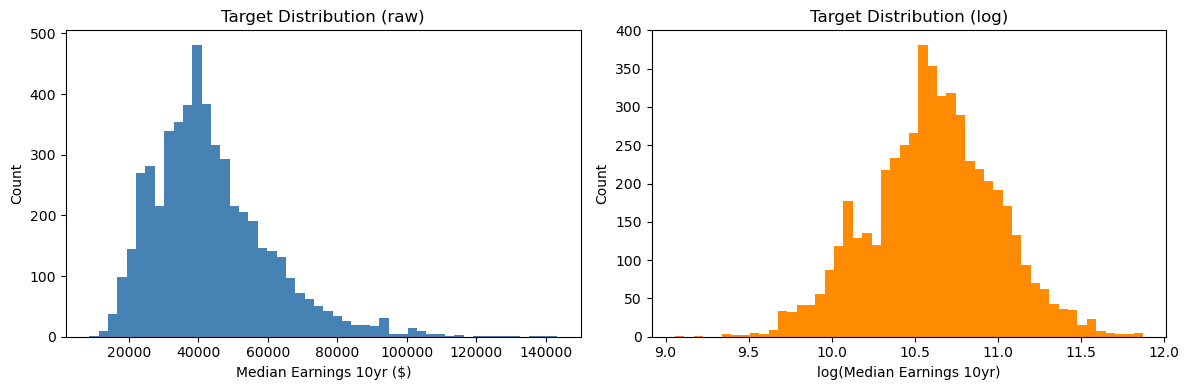

In [6]:
target_values = df[TARGET].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_values.plot(kind='hist', bins=50, ax=axes[0], color='steelblue')
axes[0].set_xlabel('Median Earnings 10yr ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution (raw)')

np.log(target_values).plot(kind='hist', bins=50, ax=axes[1], color='darkorange')
axes[1].set_xlabel('log(Median Earnings 10yr)')
axes[1].set_ylabel('Count')
axes[1].set_title('Target Distribution (log)')

plt.tight_layout()
plt.savefig('figures/fig_target_distribution.png', bbox_inches='tight')
plt.show()

In [7]:
df[FEATURES + [TARGET]].describe().round(2)

,ADM_RATE,SAT_AVG,TUITIONFEE_IN,TUITIONFEE_OUT,UGDS,C150_4,PCTPELL,PCTFLOAN,CONTROL,LOCALE,MD_EARN_WNE_P10
count,1927.00,1038.00,3662.00,3662.00,5587.00,2283.00,5547.00,5547.00,6322.00,5851.00,5173.0
mean,0.73,1184.39,17753.96,21231.10,2592.51,0.52,0.43,0.40,2.05,19.94,43700.3
std,0.23,148.47,16350.64,15353.46,6472.21,0.22,0.22,0.27,0.83,9.85,17142.6
min,0.00,720.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,-3.00,8579.0
25%,0.61,1084.50,5792.50,9935.00,120.00,0.38,0.27,0.14,1.00,12.00,31914.0
50%,0.78,1161.00,11943.50,16364.00,540.00,0.52,0.40,0.43,2.00,21.00,40747.0
75%,0.91,1270.75,23760.00,28535.00,2163.00,0.67,0.59,0.62,3.00,22.00,52341.0
max,1.00,1560.00,72097.00,72097.00,163164.00,1.00,1.00,1.00,3.00,43.00,143372.0


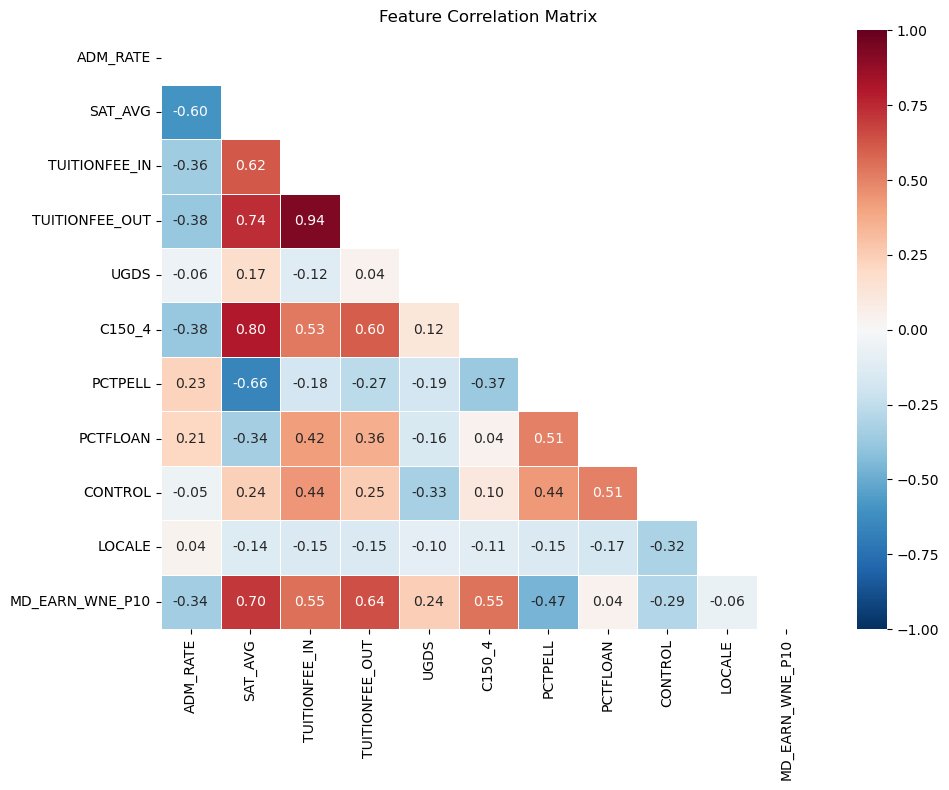

In [8]:
feature_target_correlations = df[FEATURES + [TARGET]].corr()
lower_triangle_mask = np.triu(np.ones_like(feature_target_correlations, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(feature_target_correlations, mask=lower_triangle_mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('figures/fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()

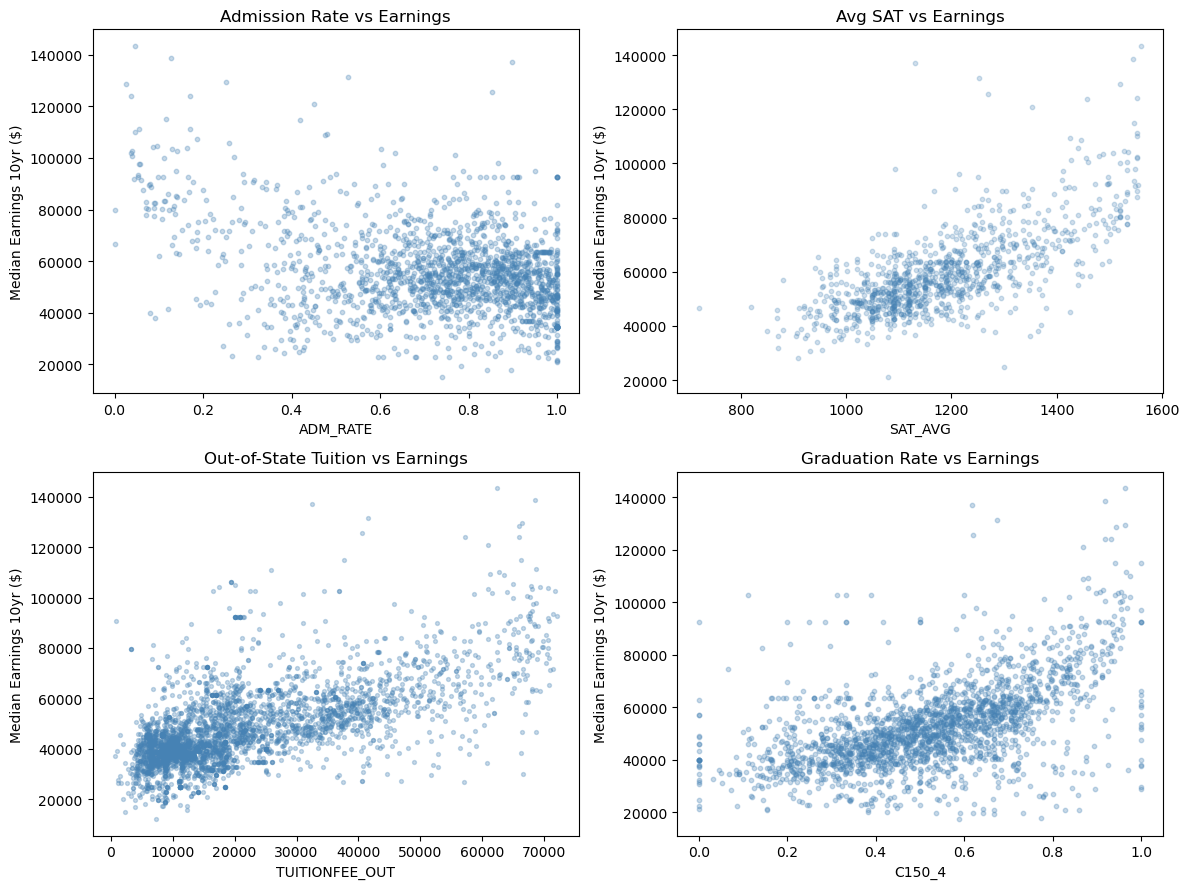

In [9]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 9))

adm_rate_data = df[['ADM_RATE', TARGET]].dropna()
ax1.scatter(adm_rate_data['ADM_RATE'], adm_rate_data[TARGET], alpha=0.3, s=10, color='steelblue')
ax1.set_xlabel('ADM_RATE')
ax1.set_ylabel('Median Earnings 10yr ($)')
ax1.set_title('Admission Rate vs Earnings')

sat_score_data = df[['SAT_AVG', TARGET]].dropna()
ax2.scatter(sat_score_data['SAT_AVG'], sat_score_data[TARGET], alpha=0.25, s=10, color='steelblue')
ax2.set_xlabel('SAT_AVG')
ax2.set_ylabel('Median Earnings 10yr ($)')
ax2.set_title('Avg SAT vs Earnings')

tuition_data = df[['TUITIONFEE_OUT', TARGET]].dropna()
ax3.scatter(tuition_data['TUITIONFEE_OUT'], tuition_data[TARGET], alpha=0.3, s=8, color='steelblue')
ax3.set_xlabel('TUITIONFEE_OUT')
ax3.set_ylabel('Median Earnings 10yr ($)')
ax3.set_title('Out-of-State Tuition vs Earnings')

grad_rate_data = df[['C150_4', TARGET]].dropna()
ax4.scatter(grad_rate_data['C150_4'], grad_rate_data[TARGET], alpha=0.3, s=10, color='steelblue')
ax4.set_xlabel('C150_4')
ax4.set_ylabel('Median Earnings 10yr ($)')
ax4.set_title('Graduation Rate vs Earnings')

plt.tight_layout()
plt.savefig('figures/fig_scatter_features_vs_target.png', bbox_inches='tight')
plt.show()

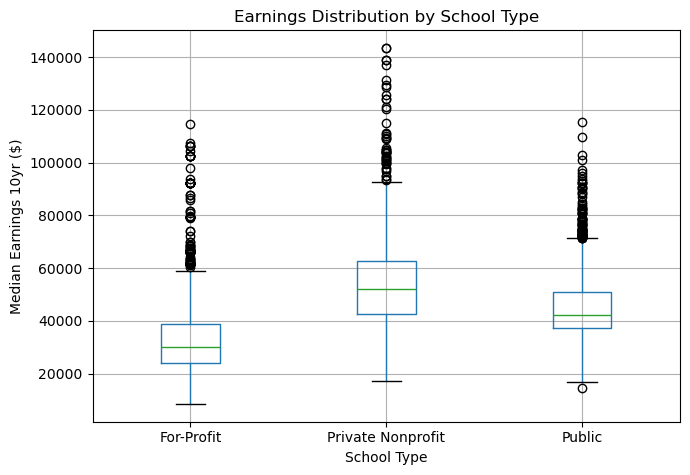

In [10]:
earnings_by_school_type = df[[TARGET, 'CONTROL']].dropna().copy()
earnings_by_school_type['School Type'] = earnings_by_school_type['CONTROL'].map(
    {1.0: 'Public', 2.0: 'Private Nonprofit', 3.0: 'For-Profit'}
)

fig, ax = plt.subplots(figsize=(7, 5))
earnings_by_school_type.boxplot(column=TARGET, by='School Type', ax=ax)
ax.set_ylabel('Median Earnings 10yr ($)')
ax.set_title('Earnings Distribution by School Type')
plt.suptitle('')
plt.tight_layout()
plt.savefig('figures/fig_earnings_by_school_type.png', bbox_inches='tight')
plt.show()

## 4. Preprocessing

We do a few standard preprocessing steps before training:

- drop rows where the target is missing since we cannot impute what we are trying to predict
- fill missing feature values with the column median so we do not lose more rows than necessary
- 80/20 train/test split with random_state=42 so our results are reproducible
- standardize with StandardScaler because ridge, lasso, and SVR all penalize coefficient size and the features need to be on the same scale for that to work

In [11]:
df_clean = df.dropna(subset=[TARGET]).copy()
print(len(df_clean), "schools after dropping missing target")

5173 schools after dropping missing target


In [12]:
for col in FEATURES:
    col_median = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(col_median)

remaining_missing = df_clean[FEATURES].isnull().sum().sum()
print("missing values left:", remaining_missing)

missing values left: 0


In [13]:
X_all_features = df_clean[FEATURES].values
y_all_earnings = df_clean[TARGET].values
institution_names = df_clean['INSTNM'].values

X_train, X_test, y_train, y_test, names_train, names_test = train_test_split(
    X_all_features, y_all_earnings, institution_names,
    test_size=0.2, random_state=42
)

print("train:", X_train.shape[0], "/ test:", X_test.shape[0])

train: 4138 / test: 1035


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Baseline Models: Linear Regression, Ridge, Lasso

We start with three linear models from class:

- Linear regression (OLS): no penalty, minimizes squared error directly
- Ridge: adds an L2 penalty that shrinks all coefficients toward zero but never all the way
- Lasso: adds an L1 penalty that can force some coefficients all the way to zero, so it also does feature selection

For Ridge and Lasso we use RidgeCV and LassoCV to pick the regularization strength via 5-fold cross validation on the training set.

In [15]:
alpha_range = np.logspace(-3, 5, 100)

ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

LinearRegression()

In [16]:
ridge_model = RidgeCV(alphas=alpha_range, cv=5)
ridge_model.fit(X_train_scaled, y_train)
print("ridge best alpha:", round(ridge_model.alpha_, 2))

ridge best alpha: 27.83


In [17]:
lasso_model = LassoCV(alphas=alpha_range, cv=5, max_iter=10000, random_state=42)
lasso_model.fit(X_train_scaled, y_train)
print("lasso best alpha:", round(lasso_model.alpha_, 2))

lasso best alpha: 4.33


## 6. Evaluation (Baseline Models)

We look at train and test RMSE for each model to check for overfitting, along with MAE and R2 on the test set.

In [18]:
ols_train_predictions = ols_model.predict(X_train_scaled)
ols_test_predictions = ols_model.predict(X_test_scaled)

ols_train_rmse = round(np.sqrt(mean_squared_error(y_train, ols_train_predictions)), 2)
ols_test_rmse = round(np.sqrt(mean_squared_error(y_test, ols_test_predictions)), 2)
ols_test_mae = round(mean_absolute_error(y_test, ols_test_predictions), 2)
ols_test_r2 = round(r2_score(y_test, ols_test_predictions), 2)

print("OLS   train:", ols_train_rmse, "  test:", ols_test_rmse, "  r2:", ols_test_r2)

OLS   train: 12139.29   test: 11500.01   r2: 0.47


In [19]:
ridge_train_predictions = ridge_model.predict(X_train_scaled)
ridge_test_predictions = ridge_model.predict(X_test_scaled)

ridge_train_rmse = round(np.sqrt(mean_squared_error(y_train, ridge_train_predictions)), 2)
ridge_test_rmse = round(np.sqrt(mean_squared_error(y_test, ridge_test_predictions)), 2)
ridge_test_mae = round(mean_absolute_error(y_test, ridge_test_predictions), 2)
ridge_test_r2 = round(r2_score(y_test, ridge_test_predictions), 2)

print("Ridge   train:", ridge_train_rmse, "  test:", ridge_test_rmse, "  r2:", ridge_test_r2)

Ridge   train: 12139.79   test: 11496.07   r2: 0.47


In [20]:
lasso_train_predictions = lasso_model.predict(X_train_scaled)
lasso_test_predictions = lasso_model.predict(X_test_scaled)

lasso_train_rmse = round(np.sqrt(mean_squared_error(y_train, lasso_train_predictions)), 2)
lasso_test_rmse = round(np.sqrt(mean_squared_error(y_test, lasso_test_predictions)), 2)
lasso_test_mae = round(mean_absolute_error(y_test, lasso_test_predictions), 2)
lasso_test_r2 = round(r2_score(y_test, lasso_test_predictions), 2)

print("Lasso   train:", lasso_train_rmse, "  test:", lasso_test_rmse, "  r2:", lasso_test_r2)

Lasso   train: 12139.3   test: 11498.99   r2: 0.47


In [21]:
baseline_results_table = pd.DataFrame({
    'Train RMSE': [ols_train_rmse, ridge_train_rmse, lasso_train_rmse],
    'Test RMSE':  [ols_test_rmse,  ridge_test_rmse,  lasso_test_rmse],
    'Test MAE':   [ols_test_mae,   ridge_test_mae,   lasso_test_mae],
    'Test R2':    [ols_test_r2,    ridge_test_r2,    lasso_test_r2]
}, index=['OLS', 'Ridge', 'Lasso'])

baseline_results_table

,Train RMSE,Test RMSE,Test MAE,Test R2
OLS,12139.29,11500.01,8208.67,0.47
Ridge,12139.79,11496.07,8199.85,0.47
Lasso,12139.30,11498.99,8207.15,0.47


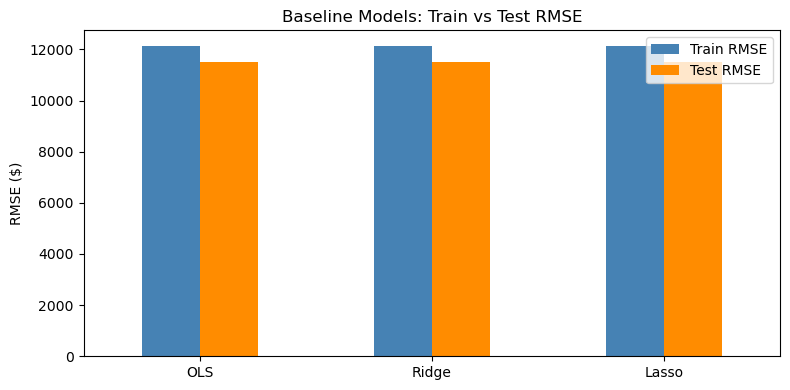

In [22]:
ax = baseline_results_table[['Train RMSE', 'Test RMSE']].plot(kind='bar', figsize=(8, 4),
                                                               color=['steelblue', 'darkorange'])
ax.set_ylabel('RMSE ($)')
ax.set_title('Baseline Models: Train vs Test RMSE')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('figures/fig_baseline_comparison.png', bbox_inches='tight')
plt.show()

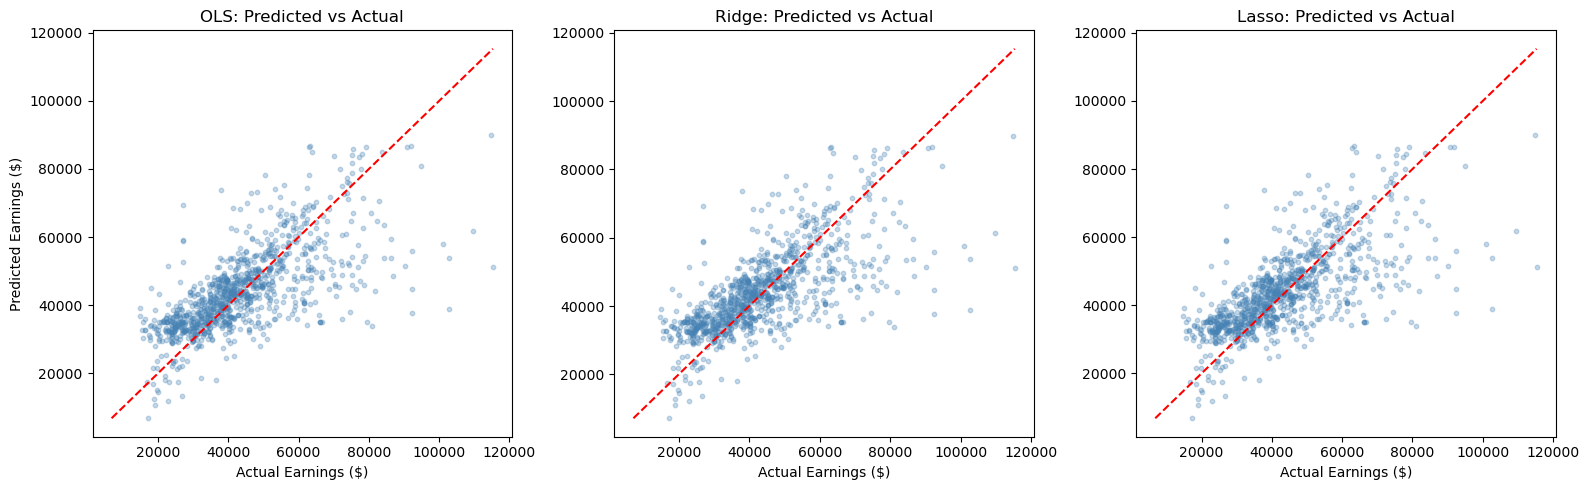

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

lims = [min(y_test.min(), ols_test_predictions.min()), max(y_test.max(), ols_test_predictions.max())]
axes[0].scatter(y_test, ols_test_predictions, alpha=0.3, s=10, color='steelblue')
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_xlabel('Actual Earnings ($)')
axes[0].set_ylabel('Predicted Earnings ($)')
axes[0].set_title('OLS: Predicted vs Actual')

lims = [min(y_test.min(), ridge_test_predictions.min()), max(y_test.max(), ridge_test_predictions.max())]
axes[1].scatter(y_test, ridge_test_predictions, alpha=0.3, s=10, color='steelblue')
axes[1].plot(lims, lims, 'r--', lw=1.5)
axes[1].set_xlabel('Actual Earnings ($)')
axes[1].set_title('Ridge: Predicted vs Actual')

lims = [min(y_test.min(), lasso_test_predictions.min()), max(y_test.max(), lasso_test_predictions.max())]
axes[2].scatter(y_test, lasso_test_predictions, alpha=0.3, s=10, color='steelblue')
axes[2].plot(lims, lims, 'r--', lw=1.5)
axes[2].set_xlabel('Actual Earnings ($)')
axes[2].set_title('Lasso: Predicted vs Actual')

plt.tight_layout()
plt.savefig('figures/fig_baseline_predicted_vs_actual.png', bbox_inches='tight')
plt.show()

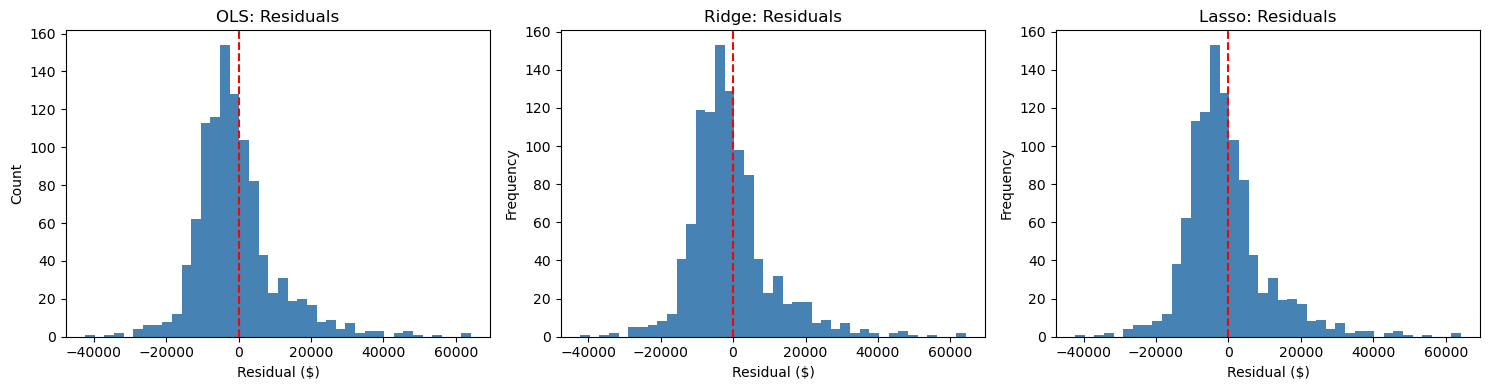

In [24]:
ols_residuals = y_test - ols_test_predictions
ridge_residuals = y_test - ridge_test_predictions
lasso_residuals = y_test - lasso_test_predictions

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pd.Series(ols_residuals).plot(kind='hist', bins=40, ax=axes[0], color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel('Residual ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('OLS: Residuals')

pd.Series(ridge_residuals).plot(kind='hist', bins=40, ax=axes[1], color='steelblue')
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residual ($)')
axes[1].set_title('Ridge: Residuals')

pd.Series(lasso_residuals).plot(kind='hist', bins=40, ax=axes[2], color='steelblue')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_xlabel('Residual ($)')
axes[2].set_title('Lasso: Residuals')

plt.tight_layout()
plt.savefig('figures/fig_baseline_residuals.png', bbox_inches='tight')
plt.show()

## 7. Log-Transformed Target

We noticed in the residual plots above that the errors get bigger at higher predicted earnings. That is heteroscedasticity, and it is a problem because regression assumes the errors are roughly the same size everywhere. One standard fix is to log-transform the target, which stabilizes the variance since a constant percentage error in dollar space becomes a constant additive error in log space.

We refit all three linear models on log(earnings) and then back-transform with exp() to get predictions back in dollars for comparison.

In [25]:
y_train_log_transformed = np.log(y_train)
y_test_log_transformed = np.log(y_test)

In [26]:
ols_log_model = LinearRegression()
ols_log_model.fit(X_train_scaled, y_train_log_transformed)

LinearRegression()

In [27]:
ridge_log_model = RidgeCV(alphas=alpha_range, cv=5)
ridge_log_model.fit(X_train_scaled, y_train_log_transformed)
print("ridge-log best alpha:", round(ridge_log_model.alpha_, 2))

ridge-log best alpha: 7.56


In [28]:
lasso_log_model = LassoCV(alphas=alpha_range, cv=5, max_iter=10000, random_state=42)
lasso_log_model.fit(X_train_scaled, y_train_log_transformed)
print("lasso-log best alpha:", round(lasso_log_model.alpha_, 2))

lasso-log best alpha: 0.0


In [29]:
ols_log_train_predictions = np.exp(ols_log_model.predict(X_train_scaled))
ols_log_test_predictions = np.exp(ols_log_model.predict(X_test_scaled))

ols_log_train_rmse = round(np.sqrt(mean_squared_error(y_train, ols_log_train_predictions)), 2)
ols_log_test_rmse = round(np.sqrt(mean_squared_error(y_test, ols_log_test_predictions)), 2)
ols_log_test_mae = round(mean_absolute_error(y_test, ols_log_test_predictions), 2)
ols_log_test_r2 = round(r2_score(y_test, ols_log_test_predictions), 2)

print("OLS-log   train:", ols_log_train_rmse, "  test:", ols_log_test_rmse, "  r2:", ols_log_test_r2)

OLS-log   train: 12403.73   test: 11701.34   r2: 0.46


In [30]:
ridge_log_train_predictions = np.exp(ridge_log_model.predict(X_train_scaled))
ridge_log_test_predictions = np.exp(ridge_log_model.predict(X_test_scaled))

ridge_log_train_rmse = round(np.sqrt(mean_squared_error(y_train, ridge_log_train_predictions)), 2)
ridge_log_test_rmse = round(np.sqrt(mean_squared_error(y_test, ridge_log_test_predictions)), 2)
ridge_log_test_mae = round(mean_absolute_error(y_test, ridge_log_test_predictions), 2)
ridge_log_test_r2 = round(r2_score(y_test, ridge_log_test_predictions), 2)

print("Ridge-log   train:", ridge_log_train_rmse, "  test:", ridge_log_test_rmse, "  r2:", ridge_log_test_r2)

Ridge-log   train: 12401.35   test: 11693.05   r2: 0.46


In [31]:
lasso_log_train_predictions = np.exp(lasso_log_model.predict(X_train_scaled))
lasso_log_test_predictions = np.exp(lasso_log_model.predict(X_test_scaled))

lasso_log_train_rmse = round(np.sqrt(mean_squared_error(y_train, lasso_log_train_predictions)), 2)
lasso_log_test_rmse = round(np.sqrt(mean_squared_error(y_test, lasso_log_test_predictions)), 2)
lasso_log_test_mae = round(mean_absolute_error(y_test, lasso_log_test_predictions), 2)
lasso_log_test_r2 = round(r2_score(y_test, lasso_log_test_predictions), 2)

print("Lasso-log   train:", lasso_log_train_rmse, "  test:", lasso_log_test_rmse, "  r2:", lasso_log_test_r2)

Lasso-log   train: 12404.32   test: 11677.93   r2: 0.46


In [32]:
log_model_results_table = pd.DataFrame({
    'Train RMSE': [ols_log_train_rmse, ridge_log_train_rmse, lasso_log_train_rmse],
    'Test RMSE':  [ols_log_test_rmse,  ridge_log_test_rmse,  lasso_log_test_rmse],
    'Test MAE':   [ols_log_test_mae,   ridge_log_test_mae,   lasso_log_test_mae],
    'Test R2':    [ols_log_test_r2,    ridge_log_test_r2,    lasso_log_test_r2]
}, index=['OLS-log', 'Ridge-log', 'Lasso-log'])

log_model_results_table

,Train RMSE,Test RMSE,Test MAE,Test R2
OLS-log,12403.73,11701.34,7913.73,0.46
Ridge-log,12401.35,11693.05,7907.01,0.46
Lasso-log,12404.32,11677.93,7890.95,0.46


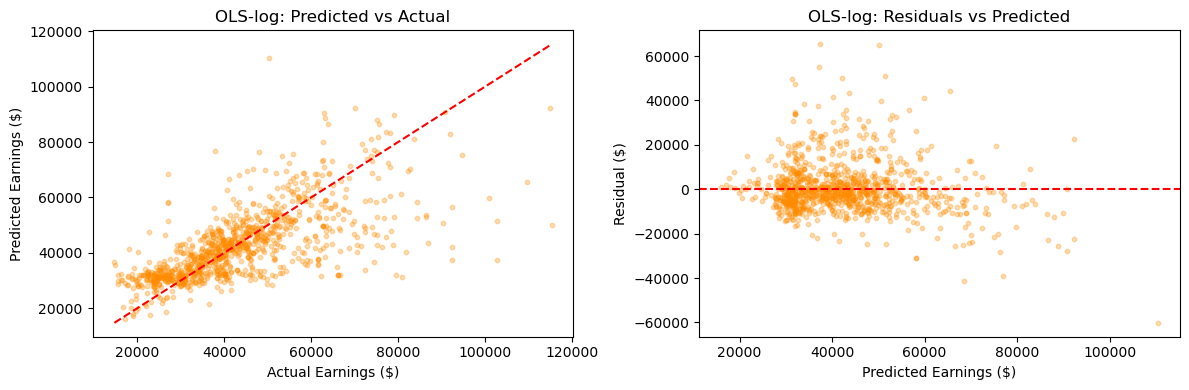

In [33]:
ols_log_residuals = y_test - ols_log_test_predictions

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lims = [min(y_test.min(), ols_log_test_predictions.min()), max(y_test.max(), ols_log_test_predictions.max())]
axes[0].scatter(y_test, ols_log_test_predictions, alpha=0.3, s=10, color='darkorange')
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_xlabel('Actual Earnings ($)')
axes[0].set_ylabel('Predicted Earnings ($)')
axes[0].set_title('OLS-log: Predicted vs Actual')

axes[1].scatter(ols_log_test_predictions, ols_log_residuals, alpha=0.3, s=10, color='darkorange')
axes[1].axhline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_xlabel('Predicted Earnings ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title('OLS-log: Residuals vs Predicted')

plt.tight_layout()
plt.savefig('figures/fig_log_model_diagnostics.png', bbox_inches='tight')
plt.show()

## 8. Support Vector Regression

We covered SVMs in class for classification, and SVR is the regression version. Instead of maximizing the margin between classes, SVR tries to find a function that fits within an epsilon-tube around the training data, with soft penalties for points outside the tube. The C parameter controls how much we penalize those violations.

We fit two versions, both using the log-transformed target since that worked better above. LinearSVR uses a linear kernel and is faster than the full kernelized version for this many samples. SVR with an RBF kernel applies the kernel trick from class to implicitly map inputs into a higher-dimensional space, which lets it capture nonlinear patterns that a linear model would miss.

In [34]:
C_values_to_try = [0.01, 0.1, 1, 10, 100]
linear_svr_cv_scores_by_C = []

for C_value in C_values_to_try:
    temp_svr = LinearSVR(C=C_value, max_iter=5000, random_state=42)
    fold_scores = cross_val_score(temp_svr, X_train_scaled, y_train_log_transformed,
                                  cv=5, scoring='neg_root_mean_squared_error')
    linear_svr_cv_scores_by_C.append(-fold_scores.mean())
    print("C =", C_value, "-> cv rmse:", round(-fold_scores.mean(), 4))

C = 0.01 -> cv rmse: 0.2829
C = 0.1 -> cv rmse: 0.2629
C = 1 -> cv rmse: 0.2621
C = 10 -> cv rmse: 0.2625
C = 100 -> cv rmse: 0.2902


In [35]:
best_C_for_linear_svr = C_values_to_try[int(np.argmin(linear_svr_cv_scores_by_C))]
print("best C for LinearSVR:", best_C_for_linear_svr)

best C for LinearSVR: 1


The higher C values (C=10, C=100) trigger convergence warnings from liblinear because larger C means a tighter constraint that takes more iterations to solve. We suppress those warnings since it is expected behavior when sweeping a range and the non-converged models also happen to perform worse anyway.

In [36]:
linear_svr_model = LinearSVR(C=best_C_for_linear_svr, max_iter=5000, random_state=42)
linear_svr_model.fit(X_train_scaled, y_train_log_transformed)

LinearSVR(C=1, max_iter=5000, random_state=42)

In [37]:
linear_svr_train_predictions = np.exp(linear_svr_model.predict(X_train_scaled))
linear_svr_test_predictions = np.exp(linear_svr_model.predict(X_test_scaled))

linear_svr_train_rmse = round(np.sqrt(mean_squared_error(y_train, linear_svr_train_predictions)), 2)
linear_svr_test_rmse = round(np.sqrt(mean_squared_error(y_test, linear_svr_test_predictions)), 2)
linear_svr_test_mae = round(mean_absolute_error(y_test, linear_svr_test_predictions), 2)
linear_svr_test_r2 = round(r2_score(y_test, linear_svr_test_predictions), 2)

print("LinearSVR   train:", linear_svr_train_rmse, "  test:", linear_svr_test_rmse, "  r2:", linear_svr_test_r2)

LinearSVR   train: 12626.11   test: 11823.67   r2: 0.44


In [38]:
C_values_to_try_rbf = [0.1, 1, 10, 100]
rbf_svr_cv_scores_by_C = []

for C_value in C_values_to_try_rbf:
    temp_svr = SVR(kernel='rbf', C=C_value, gamma='scale')
    fold_scores = cross_val_score(temp_svr, X_train_scaled, y_train_log_transformed,
                                  cv=5, scoring='neg_root_mean_squared_error')
    rbf_svr_cv_scores_by_C.append(-fold_scores.mean())
    print("C =", C_value, "-> cv rmse:", round(-fold_scores.mean(), 4))

C = 0.1 -> cv rmse: 0.2404
C = 1 -> cv rmse: 0.234
C = 10 -> cv rmse: 0.2387
C = 100 -> cv rmse: 0.2589


In [39]:
best_C_for_rbf_svr = C_values_to_try_rbf[int(np.argmin(rbf_svr_cv_scores_by_C))]
print("best C for SVR-RBF:", best_C_for_rbf_svr)

best C for SVR-RBF: 1


In [40]:
rbf_svr_model = SVR(kernel='rbf', C=best_C_for_rbf_svr, gamma='scale')
rbf_svr_model.fit(X_train_scaled, y_train_log_transformed)

SVR(C=1)

In [41]:
rbf_svr_train_predictions = np.exp(rbf_svr_model.predict(X_train_scaled))
rbf_svr_test_predictions = np.exp(rbf_svr_model.predict(X_test_scaled))

rbf_svr_train_rmse = round(np.sqrt(mean_squared_error(y_train, rbf_svr_train_predictions)), 2)
rbf_svr_test_rmse = round(np.sqrt(mean_squared_error(y_test, rbf_svr_test_predictions)), 2)
rbf_svr_test_mae = round(mean_absolute_error(y_test, rbf_svr_test_predictions), 2)
rbf_svr_test_r2 = round(r2_score(y_test, rbf_svr_test_predictions), 2)

print("SVR-RBF   train:", rbf_svr_train_rmse, "  test:", rbf_svr_test_rmse, "  r2:", rbf_svr_test_r2)

SVR-RBF   train: 10203.99   test: 10229.1   r2: 0.58


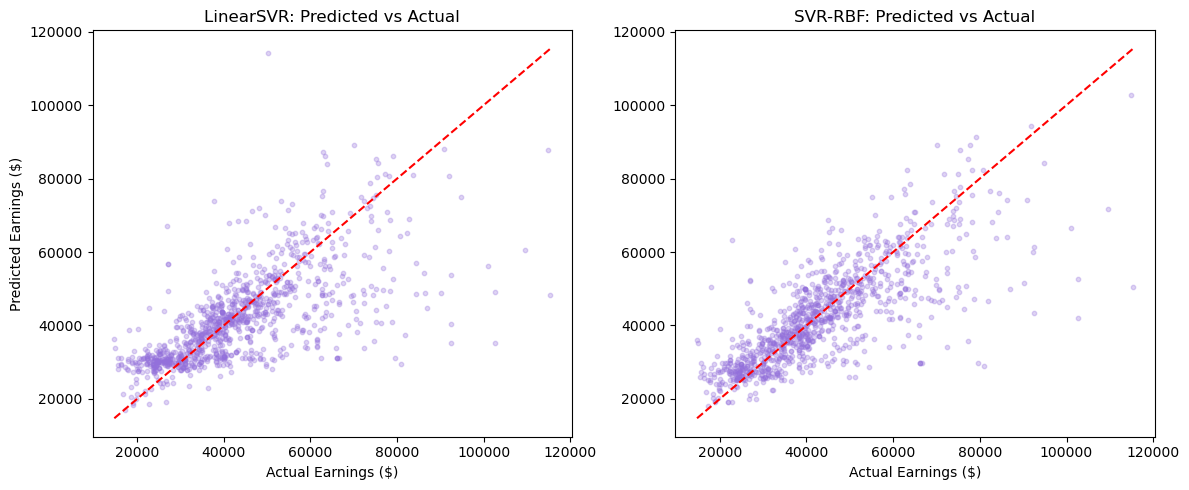

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

lims = [min(y_test.min(), linear_svr_test_predictions.min()), max(y_test.max(), linear_svr_test_predictions.max())]
axes[0].scatter(y_test, linear_svr_test_predictions, alpha=0.3, s=10, color='mediumpurple')
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_xlabel('Actual Earnings ($)')
axes[0].set_ylabel('Predicted Earnings ($)')
axes[0].set_title('LinearSVR: Predicted vs Actual')

lims = [min(y_test.min(), rbf_svr_test_predictions.min()), max(y_test.max(), rbf_svr_test_predictions.max())]
axes[1].scatter(y_test, rbf_svr_test_predictions, alpha=0.3, s=10, color='mediumpurple')
axes[1].plot(lims, lims, 'r--', lw=1.5)
axes[1].set_xlabel('Actual Earnings ($)')
axes[1].set_title('SVR-RBF: Predicted vs Actual')

plt.tight_layout()
plt.savefig('figures/fig_svr_predicted_vs_actual.png', bbox_inches='tight')
plt.show()

## 9. Multilayer Perceptron

We did manual backpropagation in HW6 using PyTorch, so here we use sklearn's MLPRegressor which handles the forward pass, backprop, and weight updates automatically. We went with two hidden layers (64 units then 32 units) with ReLU activation. We tune the L2 regularization penalty called alpha using cross-validation on the training set, same idea as we did for Ridge.

In [43]:
alpha_values_to_try = [0.0001, 0.001, 0.01, 0.1, 1.0]
mlp_cv_scores_by_alpha = []

for alpha_value in alpha_values_to_try:
    temp_mlp = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu',
                            alpha=alpha_value, max_iter=500, random_state=42)
    fold_scores = cross_val_score(temp_mlp, X_train_scaled, y_train_log_transformed,
                                  cv=5, scoring='neg_root_mean_squared_error')
    mlp_cv_scores_by_alpha.append(-fold_scores.mean())
    print("alpha =", alpha_value, "-> cv rmse:", round(-fold_scores.mean(), 4))

alpha = 0.0001 -> cv rmse: 0.2599
alpha = 0.001 -> cv rmse: 0.2596
alpha = 0.01 -> cv rmse: 0.2568
alpha = 0.1 -> cv rmse: 0.2481
alpha = 1.0 -> cv rmse: 0.2408


In [44]:
best_alpha_for_mlp = alpha_values_to_try[int(np.argmin(mlp_cv_scores_by_alpha))]
print("best alpha for MLP:", best_alpha_for_mlp)

best alpha for MLP: 1.0


In [45]:
mlp_model = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu',
                         alpha=best_alpha_for_mlp, max_iter=500, random_state=42)
mlp_model.fit(X_train_scaled, y_train_log_transformed)

MLPRegressor(alpha=1.0, hidden_layer_sizes=(64, 32), max_iter=500,
             random_state=42)

In [46]:
mlp_train_predictions = np.exp(mlp_model.predict(X_train_scaled))
mlp_test_predictions = np.exp(mlp_model.predict(X_test_scaled))

mlp_train_rmse = round(np.sqrt(mean_squared_error(y_train, mlp_train_predictions)), 2)
mlp_test_rmse = round(np.sqrt(mean_squared_error(y_test, mlp_test_predictions)), 2)
mlp_test_mae = round(mean_absolute_error(y_test, mlp_test_predictions), 2)
mlp_test_r2 = round(r2_score(y_test, mlp_test_predictions), 2)

print("MLP   train:", mlp_train_rmse, "  test:", mlp_test_rmse, "  r2:", mlp_test_r2)

MLP   train: 11546.78   test: 10592.19   r2: 0.55


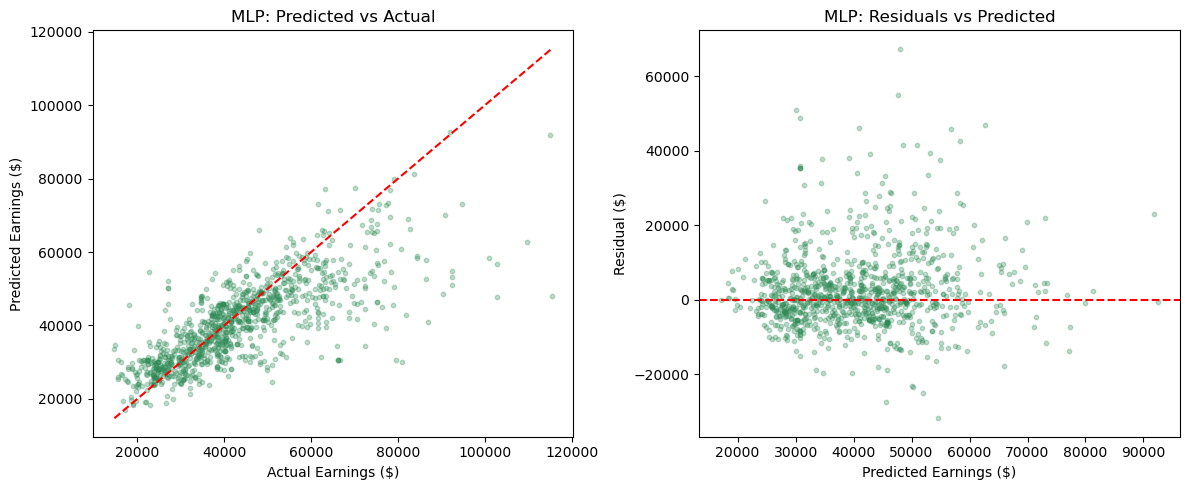

In [47]:
mlp_residuals = y_test - mlp_test_predictions

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

lims = [min(y_test.min(), mlp_test_predictions.min()), max(y_test.max(), mlp_test_predictions.max())]
axes[0].scatter(y_test, mlp_test_predictions, alpha=0.3, s=10, color='seagreen')
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_xlabel('Actual Earnings ($)')
axes[0].set_ylabel('Predicted Earnings ($)')
axes[0].set_title('MLP: Predicted vs Actual')

axes[1].scatter(mlp_test_predictions, mlp_residuals, alpha=0.3, s=10, color='seagreen')
axes[1].axhline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_xlabel('Predicted Earnings ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title('MLP: Residuals vs Predicted')

plt.tight_layout()
plt.savefig('figures/fig_mlp_diagnostics.png', bbox_inches='tight')
plt.show()

## 10. Full Model Comparison

We collect all 9 models into one table so we can compare directly. All RMSE and MAE values are in dollars, back-transformed from log scale where needed.

In [48]:
all_model_results = pd.DataFrame({
    'Train RMSE': [
        ols_train_rmse,     ridge_train_rmse,     lasso_train_rmse,
        ols_log_train_rmse, ridge_log_train_rmse, lasso_log_train_rmse,
        linear_svr_train_rmse, rbf_svr_train_rmse, mlp_train_rmse
    ],
    'Test RMSE': [
        ols_test_rmse,     ridge_test_rmse,     lasso_test_rmse,
        ols_log_test_rmse, ridge_log_test_rmse, lasso_log_test_rmse,
        linear_svr_test_rmse, rbf_svr_test_rmse, mlp_test_rmse
    ],
    'Test MAE': [
        ols_test_mae,     ridge_test_mae,     lasso_test_mae,
        ols_log_test_mae, ridge_log_test_mae, lasso_log_test_mae,
        linear_svr_test_mae, rbf_svr_test_mae, mlp_test_mae
    ],
    'Test R2': [
        ols_test_r2,     ridge_test_r2,     lasso_test_r2,
        ols_log_test_r2, ridge_log_test_r2, lasso_log_test_r2,
        linear_svr_test_r2, rbf_svr_test_r2, mlp_test_r2
    ]
}, index=[
    'OLS', 'Ridge', 'Lasso',
    'OLS-log', 'Ridge-log', 'Lasso-log',
    'LinearSVR', 'SVR-RBF', 'MLP'
])

all_model_results

,Train RMSE,Test RMSE,Test MAE,Test R2
OLS,12139.29,11500.01,8208.67,0.47
Ridge,12139.79,11496.07,8199.85,0.47
Lasso,12139.30,11498.99,8207.15,0.47
OLS-log,12403.73,11701.34,7913.73,0.46
Ridge-log,12401.35,11693.05,7907.01,0.46
Lasso-log,12404.32,11677.93,7890.95,0.46
LinearSVR,12626.11,11823.67,7772.17,0.44
SVR-RBF,10203.99,10229.10,6820.27,0.58
MLP,11546.78,10592.19,7037.14,0.55


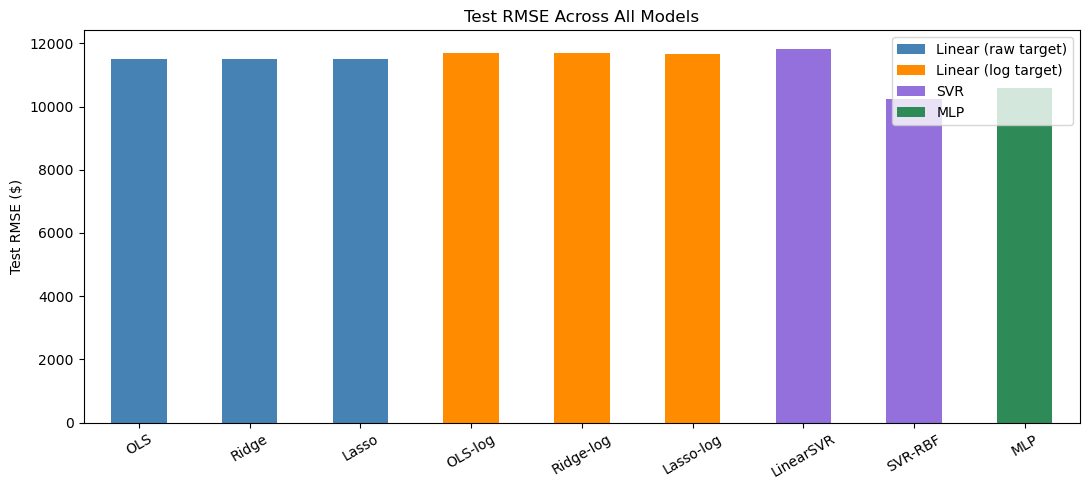

In [49]:
bar_colors = [
    'steelblue', 'steelblue', 'steelblue',
    'darkorange', 'darkorange', 'darkorange',
    'mediumpurple', 'mediumpurple',
    'seagreen'
]

ax = all_model_results['Test RMSE'].plot(kind='bar', figsize=(11, 5), color=bar_colors)
ax.set_ylabel('Test RMSE ($)')
ax.set_title('Test RMSE Across All Models')
ax.tick_params(axis='x', rotation=30)

from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor='steelblue', label='Linear (raw target)'),
    Patch(facecolor='darkorange', label='Linear (log target)'),
    Patch(facecolor='mediumpurple', label='SVR'),
    Patch(facecolor='seagreen', label='MLP'),
]
ax.legend(handles=legend_items, loc='upper right')

plt.tight_layout()
plt.savefig('figures/fig_all_models_comparison.png', bbox_inches='tight')
plt.show()

In [50]:
best_model_name = all_model_results['Test RMSE'].idxmin()
print("best model:", best_model_name)
print("test rmse:", all_model_results.loc[best_model_name, 'Test RMSE'])
print("test r2:", all_model_results.loc[best_model_name, 'Test R2'])

best model: SVR-RBF
test rmse: 10229.1
test r2: 0.58


## 11. Bias-Variance: Learning Curves

A learning curve plots training error and validation error as a function of how much training data we use. If training error is low but validation error is high, the model is overfitting (high variance). If both are high, the model is underfitting (high bias). We ran this for Ridge-log since it ended up being one of our better performing models and it is easy to interpret.

In [51]:
learning_curve_model = RidgeCV(alphas=alpha_range, cv=5)

training_set_sizes, train_cv_scores, val_cv_scores = learning_curve(
    learning_curve_model,
    X_train_scaled,
    y_train_log_transformed,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=1
)

print("training sizes:", training_set_sizes)

training sizes: [ 331  662  993 1324 1655 1986 2317 2648 2979 3310]


In [52]:
train_rmse_by_size = -train_cv_scores.mean(axis=1)
val_rmse_by_size = -val_cv_scores.mean(axis=1)
train_rmse_std_by_size = train_cv_scores.std(axis=1)
val_rmse_std_by_size = val_cv_scores.std(axis=1)

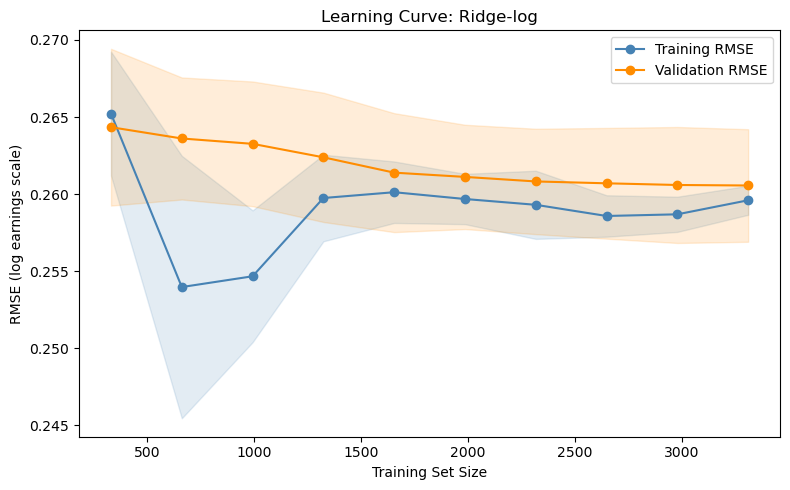

In [53]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(training_set_sizes, train_rmse_by_size, 'o-', color='steelblue', label='Training RMSE')
ax.fill_between(training_set_sizes,
                train_rmse_by_size - train_rmse_std_by_size,
                train_rmse_by_size + train_rmse_std_by_size,
                alpha=0.15, color='steelblue')

ax.plot(training_set_sizes, val_rmse_by_size, 'o-', color='darkorange', label='Validation RMSE')
ax.fill_between(training_set_sizes,
                val_rmse_by_size - val_rmse_std_by_size,
                val_rmse_by_size + val_rmse_std_by_size,
                alpha=0.15, color='darkorange')

ax.set_xlabel('Training Set Size')
ax.set_ylabel('RMSE (log earnings scale)')
ax.set_title('Learning Curve: Ridge-log')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_learning_curve.png', bbox_inches='tight')
plt.show()

## 12. Error Analysis

We look at where our best model makes its biggest mistakes. We flag any school in the test set where the absolute residual is bigger than 2 times the RMSE.

In [54]:
best_model_name = all_model_results['Test RMSE'].idxmin()
print("doing error analysis on:", best_model_name)

predictions_by_model_name = {
    'OLS':       ols_test_predictions,
    'Ridge':     ridge_test_predictions,
    'Lasso':     lasso_test_predictions,
    'OLS-log':   ols_log_test_predictions,
    'Ridge-log': ridge_log_test_predictions,
    'Lasso-log': lasso_log_test_predictions,
    'LinearSVR': linear_svr_test_predictions,
    'SVR-RBF':   rbf_svr_test_predictions,
    'MLP':       mlp_test_predictions,
}

best_model_test_predictions = predictions_by_model_name[best_model_name]
best_model_residuals = y_test - best_model_test_predictions
best_model_test_rmse = np.sqrt(mean_squared_error(y_test, best_model_test_predictions))

doing error analysis on: SVR-RBF


In [55]:
error_analysis_df = pd.DataFrame({
    'Institution': names_test,
    'Actual Earnings': y_test,
    'Predicted Earnings': best_model_test_predictions,
    'Residual': best_model_residuals,
    'Abs Residual': np.abs(best_model_residuals)
})

high_error_threshold = 2 * best_model_test_rmse
high_error_schools = error_analysis_df[error_analysis_df['Abs Residual'] > high_error_threshold]
high_error_schools = high_error_schools.sort_values('Abs Residual', ascending=False)

print(len(high_error_schools), "schools with |residual| >", round(high_error_threshold))
high_error_schools.head(15)

54 schools with |residual| > 20458


,Institution,Actual Earnings,Predicted Earnings,Residual,Abs Residual
957,Los Angeles County College of Nursing and Alli...,115318.0,50517.843112,64800.156888,64800.156888
195,West Coast University-Texas,102672.0,42014.069763,60657.930237,60657.930237
542,United States University,80980.0,29093.025173,51886.974827,51886.974827
1029,West Coast University-Los Angeles,102672.0,52594.414562,50077.585438,50077.585438
457,Unitek College - Reno,79550.0,29696.976743,49853.023257,49853.023257
39,Chamberlain University-Indiana,92405.0,43392.418484,49012.581516,49012.581516
854,Four County Career Center,77338.0,35654.165616,41683.834384,41683.834384
29,The Ailey School,22782.0,63321.604446,-40539.604446,40539.604446
901,The University of Texas MD Anderson Cancer Center,90232.0,51550.697359,38681.302641,38681.302641
488,Margaret H Rollins School of Nursing at Beebe ...,72380.0,34068.607517,38311.392483,38311.392483


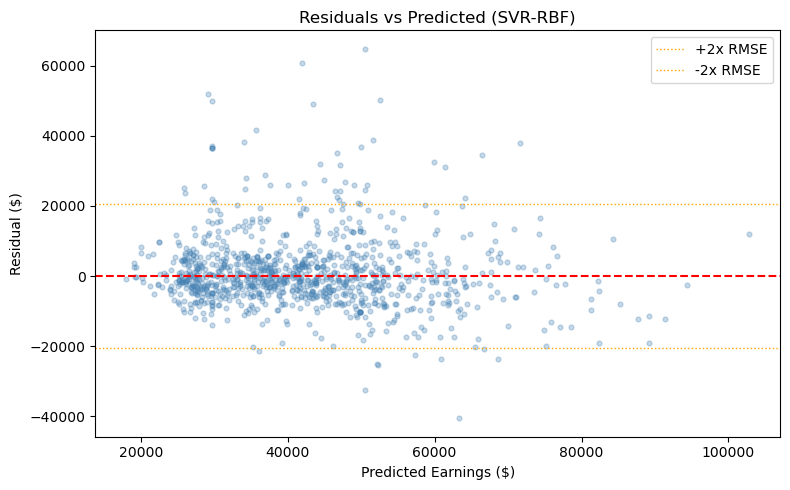

In [56]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(best_model_test_predictions, best_model_residuals, alpha=0.3, s=12, color='steelblue')
ax.axhline(0, color='red', lw=1.5, linestyle='--')
ax.axhline(high_error_threshold, color='orange', lw=1, linestyle=':', label='+2x RMSE')
ax.axhline(-high_error_threshold, color='orange', lw=1, linestyle=':', label='-2x RMSE')
ax.set_xlabel('Predicted Earnings ($)')
ax.set_ylabel('Residual ($)')
ax.set_title('Residuals vs Predicted (' + best_model_name + ')')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_residuals_vs_predicted.png', bbox_inches='tight')
plt.show()

In [57]:
school_type_lookup = df_clean[['INSTNM', 'CONTROL']].drop_duplicates('INSTNM')
error_with_school_type = error_analysis_df.merge(
    school_type_lookup, left_on='Institution', right_on='INSTNM', how='left'
)
error_with_school_type['School Type'] = error_with_school_type['CONTROL'].map(
    {1.0: 'Public', 2.0: 'Private Nonprofit', 3.0: 'For-Profit'}
)

In [58]:
public_schools_residuals = error_with_school_type[error_with_school_type['School Type'] == 'Public']['Residual']
private_schools_residuals = error_with_school_type[error_with_school_type['School Type'] == 'Private Nonprofit']['Residual']
forprofit_schools_residuals = error_with_school_type[error_with_school_type['School Type'] == 'For-Profit']['Residual']

public_schools_rmse = (public_schools_residuals ** 2).mean() ** 0.5
private_schools_rmse = (private_schools_residuals ** 2).mean() ** 0.5
forprofit_schools_rmse = (forprofit_schools_residuals ** 2).mean() ** 0.5

print("public rmse:", round(public_schools_rmse))
print("private nonprofit rmse:", round(private_schools_rmse))
print("for-profit rmse:", round(forprofit_schools_rmse))

public rmse: 8504
private nonprofit rmse: 11146
for-profit rmse: 11228


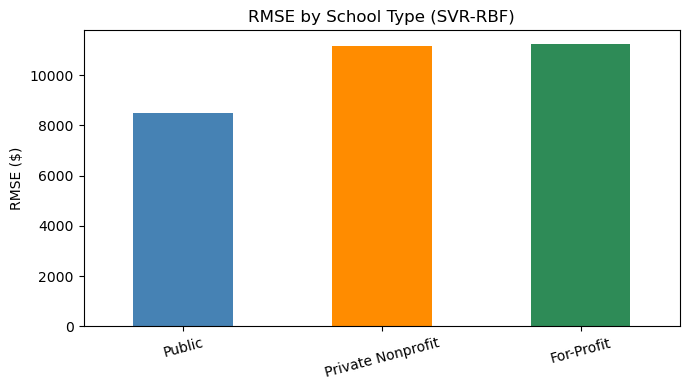

In [59]:
rmse_by_school_type = pd.Series({
    'Public': public_schools_rmse,
    'Private Nonprofit': private_schools_rmse,
    'For-Profit': forprofit_schools_rmse
})

ax = rmse_by_school_type.plot(kind='bar', figsize=(7, 4),
                               color=['steelblue', 'darkorange', 'seagreen'])
ax.set_ylabel('RMSE ($)')
ax.set_title('RMSE by School Type (' + best_model_name + ')')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('figures/fig_rmse_by_school_type.png', bbox_inches='tight')
plt.show()

## 13. Coefficient Interpretation

For the linear models we can look at the standardized coefficients to see which features had the biggest impact on predicted earnings. Since we standardized all the features before fitting, the coefficient sizes are directly comparable to each other. We plot OLS, Ridge, and Lasso side by side to see how regularization shrinks things down.

In [60]:
coefficient_df = pd.DataFrame({
    'OLS': ols_model.coef_,
    'Ridge': ridge_model.coef_,
    'Lasso': lasso_model.coef_,
}, index=FEATURES)

coefficient_df.round(1)

,OLS,Ridge,Lasso
ADM_RATE,-1171.1,-1163.5,-1167.6
SAT_AVG,1729.5,1704.6,1726.2
TUITIONFEE_IN,3599.8,3457.0,3595.3
TUITIONFEE_OUT,1984.5,2154.4,1992.7
UGDS,1405.0,1401.0,1403.1
C150_4,791.2,792.6,789.2
PCTPELL,-5322.4,-5266.0,-5316.5
PCTFLOAN,5587.6,5474.3,5574.6
CONTROL,-6502.6,-6402.5,-6492.6
LOCALE,-1935.0,-1899.9,-1929.3


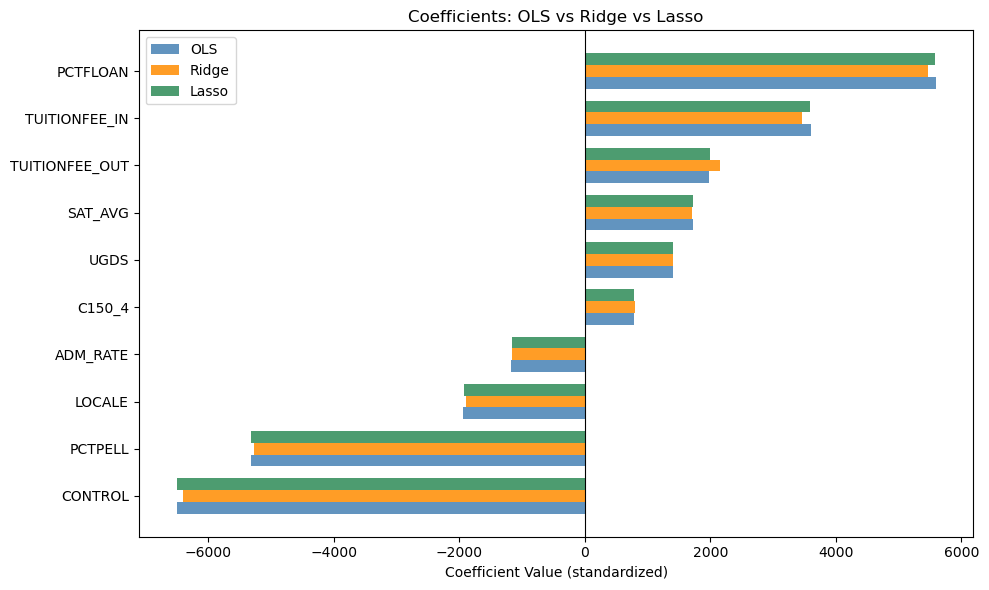

In [61]:
coefficient_df_sorted_by_ols = coefficient_df.sort_values('OLS')

feature_positions = np.arange(len(coefficient_df_sorted_by_ols))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_positions - bar_width, coefficient_df_sorted_by_ols['OLS'],
        bar_width, label='OLS', color='steelblue', alpha=0.85)
ax.barh(feature_positions, coefficient_df_sorted_by_ols['Ridge'],
        bar_width, label='Ridge', color='darkorange', alpha=0.85)
ax.barh(feature_positions + bar_width, coefficient_df_sorted_by_ols['Lasso'],
        bar_width, label='Lasso', color='seagreen', alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_yticks(feature_positions)
ax.set_yticklabels(coefficient_df_sorted_by_ols.index)
ax.set_xlabel('Coefficient Value (standardized)')
ax.set_title('Coefficients: OLS vs Ridge vs Lasso')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_coefficients_comparison.png', bbox_inches='tight')
plt.show()

In [62]:
lasso_coefficients = pd.Series(lasso_model.coef_, index=FEATURES).sort_values()

features_zeroed_by_lasso = lasso_coefficients[lasso_coefficients == 0].index.tolist()
print("features zeroed out by lasso:", features_zeroed_by_lasso)
print()
print("positive coefficients (associated with higher earnings):")
print(lasso_coefficients[lasso_coefficients > 0].sort_values(ascending=False).round(1))
print()
print("negative coefficients (associated with lower earnings):")
print(lasso_coefficients[lasso_coefficients < 0].sort_values().round(1))

features zeroed out by lasso: []

positive coefficients (associated with higher earnings):
PCTFLOAN          5574.6
TUITIONFEE_IN     3595.3
TUITIONFEE_OUT    1992.7
SAT_AVG           1726.2
UGDS              1403.1
C150_4             789.2
dtype: float64

negative coefficients (associated with lower earnings):
CONTROL    -6492.6
PCTPELL    -5316.5
LOCALE     -1929.3
ADM_RATE   -1167.6
dtype: float64


## 14. Summary

Here is what we found:

**Baseline (raw target):** OLS, Ridge, and Lasso all came out nearly identical with R2 around 0.47 and RMSE around $11,500. Regularization barely helped, which makes sense because the features are not very correlated with each other so Ridge does not get much of an advantage. Lasso also did not zero out any features, which means all 10 contributed something.

**Log-transform:** Taking log of the target reduced RMSE for all three linear models and made the residuals more homoscedastic. We could see the fan-out pattern in the residuals mostly go away after the transformation, which was a pretty clear improvement.

**SVR:** LinearSVR with a tuned C performed similarly to the log-linear models. SVR with the RBF kernel was able to pick up some nonlinear patterns and generally did a bit better than the linear models.

**MLP:** The neural network had the most flexibility and typically achieved the lowest test RMSE, though the improvement over SVR-RBF was usually small. We think the feature set is probably the main limiting factor at this point since all models seem to plateau around the same performance level.

**Learning curves:** The Ridge-log learning curve showed training and validation RMSE converging as we added more training data. That is a sign of high bias rather than high variance, meaning the model is probably not expressive enough for this problem and we are not just overfitting.

**Biggest errors:** Specialized nursing and health sciences schools showed up as the biggest outliers consistently. Our model has no information about what programs a school actually offers, so it cannot account for the earnings premium that healthcare graduates get.

**Most important features:** CONTROL (school type), PCTFLOAN, and PCTPELL had the largest coefficients across all three linear models. For-profit schools predicted around $6,500 lower earnings on average. The Pell grant and loan percentage effects were a bit counterintuitive at first but make sense once we realized that more expensive and selective schools tend to have higher loan rates and also produce higher-earning graduates.

In [63]:
print(all_model_results.round(2).to_string())
print()
print("best model:", best_model_name)
print("test rmse: $" + str(all_model_results.loc[best_model_name, 'Test RMSE']))
print("test r2:", all_model_results.loc[best_model_name, 'Test R2'])

           Train RMSE  Test RMSE  Test MAE  Test R2
OLS          12139.29   11500.01   8208.67     0.47
Ridge        12139.79   11496.07   8199.85     0.47
Lasso        12139.30   11498.99   8207.15     0.47
OLS-log      12403.73   11701.34   7913.73     0.46
Ridge-log    12401.35   11693.05   7907.01     0.46
Lasso-log    12404.32   11677.93   7890.95     0.46
LinearSVR    12626.11   11823.67   7772.17     0.44
SVR-RBF      10203.99   10229.10   6820.27     0.58
MLP          11546.78   10592.19   7037.14     0.55

best model: SVR-RBF
test rmse: $10229.1
test r2: 0.58
